In [ ]:
pip install sportsdataverse

In [ ]:
pip install polars

In [ ]:
pip install numpy

In [ ]:
import polars as pl
import numpy as np
from scipy.optimize import minimize_scalar
from scipy.special import expit

import requests
import matplotlib.pyplot as plt

In [5]:
def get_nl_schedule(season=2027, start_date="15.09.2026", end_date="01.03.2027", league=1, region="all"):
    url = (
        "https://data.sihf.ch/Statistic/api/cms/cache300"
        f"?alias=results&searchQuery=1,10/2015-2099/1,2,3,4,5,14,15,16,10,18,19,23,24,25,26,28,27,29,30,31,32,33,35,36,27,28,29,40,41,42,43,44,45,46,60,61,83,100,101,104105,106,107,113,114,115,116,117,118,119,120,121,122,123,124,125"
        f"&filterQuery={season}/{league}/{region}/{start_date}-{end_date}"
        "&filterBy=season,league,region,date&language=fr&format=json"
    )
    data = requests.get(url).json()["data"]

    rows = []
    for _, date, _, home, away, result, _, _, _, link, _ in data:
        rows.append({
            "date": date,
            "home_id": home["id"],
            "home_name": home["name"],
            "home_acronym": home["acronym"],
            "away_id": away["id"],
            "away_name": away["name"],
            "away_acronym": away["acronym"],
            "home_score": result["homeTeam"],
            "away_score": result["awayTeam"],
            "game_id": link["gameId"],
        })

    df = pl.DataFrame(rows).with_columns(
        pl.col("date").str.strptime(pl.Date, "%d.%m.%Y"),
        pl.col("home_score", "away_score").cast(pl.Int32, strict=False),
    )
    return df

In [6]:
sched = get_nl_schedule().drop_nulls(subset=["home_score", "away_score"])
sched 

date,home_id,home_name,home_acronym,away_id,away_name,away_acronym,home_score,away_score,game_id
date,i64,str,str,i64,str,str,i32,i32,str
2026-09-15,101150,"""HC Lugano""","""HCL""",103140,"""Genève-Servette HC""","""GSHC""",6,3,"""20271105000006"""
2026-09-15,101060,"""SC Rapperswil-Jona Lakers""","""SCRJ""",101149,"""EHC Kloten""","""EHCK""",3,4,"""20271105000004"""
2026-09-15,101151,"""HC Davos""","""HCD""",102127,"""SCL Tigers""","""SCL""",4,1,"""20271105000003"""
2026-09-15,102128,"""EHC Biel-Bienne""","""EHCB""",103138,"""Fribourg-Gottéron""","""FRI""",4,2,"""20271105000002"""
2026-09-15,103141,"""Lausanne HC""","""LHC""",101144,"""EV Zug""","""EVZ""",0,5,"""20271105000005"""
…,…,…,…,…,…,…,…,…,…
2026-10-03,102128,"""EHC Biel-Bienne""","""EHCB""",101151,"""HC Davos""","""HCD""",4,3,"""20271105000058"""
2026-10-03,101060,"""SC Rapperswil-Jona Lakers""","""SCRJ""",102126,"""SC Bern""","""SCB""",4,3,"""20271105000061"""
2026-10-03,103138,"""Fribourg-Gottéron""","""FRI""",101152,"""HC Ambri-Piotta""","""HCAP""",1,2,"""20271105000059"""


## Let's build matrice X and vector y

In [7]:
import numpy as np
from numpy.linalg import inv

In [8]:
y = sched.select(["home_score", "away_score"])
y.insert_column(2, (pl.col("home_score") - pl.col("away_score")).alias("score_diff"))
y = y.select(["score_diff"])
y = np.matrix(y.to_numpy())
print(y, y.shape)

[[ 3]
 [-1]
 [ 3]
 [ 2]
 [-5]
 [ 2]
 [-1]
 [ 2]
 [-1]
 [ 3]
 [ 3]
 [ 3]
 [-1]
 [-4]
 [-1]
 [ 1]
 [ 3]
 [ 1]
 [ 3]
 [-2]
 [-2]
 [-1]
 [-3]
 [ 1]
 [ 2]
 [-1]
 [-6]
 [ 1]
 [ 2]
 [-1]
 [ 1]
 [-3]
 [ 1]
 [ 2]
 [ 1]
 [-1]
 [-2]
 [-2]
 [ 4]
 [-3]
 [ 3]
 [-3]
 [ 3]
 [ 1]
 [ 3]
 [ 1]
 [-4]
 [ 3]
 [ 2]
 [-1]
 [-3]
 [ 3]
 [ 4]
 [ 1]
 [ 1]
 [ 1]
 [-1]
 [ 1]
 [ 1]] (59, 1)


In [9]:
teams = sorted(set(sched["home_acronym"]) | set(sched["away_acronym"]))
team_idx = {t: j + 1 for j, t in enumerate(teams)}   # column 0 is the intercept

n, p = sched.height, len(teams) + 1
X = np.zeros((n, p))
X[:, 0] = 1                                            # intercept

rows = np.arange(n)
X[rows, sched["home_acronym"].replace_strict(team_idx).to_numpy()] = 1
X[rows, sched["away_acronym"].replace_strict(team_idx).to_numpy()] = -1

X = np.matrix(X)
print(X, X.shape)

[[ 1.  0.  0.  0.  0. -1.  0.  0.  0.  1.  0.  0.  0.  0.  0.]
 [ 1.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.]
 [ 1.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0. -1.  0.  0.]
 [ 1.  1.  0.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 1.  0.  0. -1.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.]
 [ 1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -1.  0.  0.  1.]
 [ 1.  0.  0.  0.  0.  0.  1. -1.  0.  0.  0.  0.  0.  0.  0.]
 [ 1.  0.  0.  0.  1.  0.  0.  0.  0.  0. -1.  0.  0.  0.  0.]
 [ 1.  0.  0.  0.  0.  1. -1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 1.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0. -1.  0.]
 [ 1.  0.  1.  0.  0.  0.  0.  0.  0. -1.  0.  0.  0.  0.  0.]
 [ 1.  0.  0.  0.  0.  0.  0.  0. -1.  0.  0.  1.  0.  0.  0.]
 [ 1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0. -1.]
 [ 1.  0.  0. -1.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.]
 [ 1.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -1.  0.  0.]
 [ 1.  0. -1.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  

In [10]:
ref = 1 
X_red = np.delete(X, ref, axis=1)

B_red = np.linalg.solve(X_red.T @ X_red, X_red.T @ y)

B = np.insert(B_red, ref, 0.0)


In [11]:
B_flat = np.asarray(B).ravel()

home_adv = B_flat[0]
strengths = B_flat[1:] - B_flat[1:].mean()


strength_df = pl.DataFrame({
    "team_accronym": teams,
    "strength": strengths,
}).sort("strength", descending=True)

strength_df = strength_df.with_columns(
    pl.col("strength")
      .rank(method="ordinal", descending=True)
      .alias("strength_rank")
)

print(f"home advantage: {home_adv:.3f}")
with pl.Config(tbl_rows=-1):   
    print(strength_df)

home advantage: 0.430
shape: (14, 3)
┌───────────────┬───────────┬───────────────┐
│ team_accronym ┆ strength  ┆ strength_rank │
│ ---           ┆ ---       ┆ ---           │
│ str           ┆ f64       ┆ u32           │
╞═══════════════╪═══════════╪═══════════════╡
│ EVZ           ┆ 1.692161  ┆ 1             │
│ ZSC           ┆ 1.607369  ┆ 2             │
│ SCL           ┆ 0.600177  ┆ 3             │
│ FRI           ┆ 0.260986  ┆ 4             │
│ GSHC          ┆ 0.258726  ┆ 5             │
│ LHC           ┆ -0.005118 ┆ 6             │
│ HCD           ┆ -0.020083 ┆ 7             │
│ EHCB          ┆ -0.183059 ┆ 8             │
│ HCL           ┆ -0.213804 ┆ 9             │
│ HCA           ┆ -0.265925 ┆ 10            │
│ SCB           ┆ -0.379327 ┆ 11            │
│ HCAP          ┆ -0.426078 ┆ 12            │
│ SCRJ          ┆ -1.044903 ┆ 13            │
│ EHCK          ┆ -1.881122 ┆ 14            │
└───────────────┴───────────┴───────────────┘


In [12]:
standing = {"ZSC":1, "GSHC":2, "SCL":3,"HCAP":4,"HCA":5, "FRI":6,"HCD":7, "LHC":8,"SCRJ":9,"EVZ":10, "EHCB":11,"SCB":12,"HCL":13,"EHCK":14}
standing

{'ZSC': 1,
 'GSHC': 2,
 'SCL': 3,
 'HCAP': 4,
 'HCA': 5,
 'FRI': 6,
 'HCD': 7,
 'LHC': 8,
 'SCRJ': 9,
 'EVZ': 10,
 'EHCB': 11,
 'SCB': 12,
 'HCL': 13,
 'EHCK': 14}

In [13]:
strength_df = strength_df.with_columns(
    pl.col("team_accronym")
      .replace_strict(standing, return_dtype=pl.UInt32)
      .alias("standing")
)

with pl.Config(tbl_rows=-1):
    print(strength_df)

shape: (14, 4)
┌───────────────┬───────────┬───────────────┬──────────┐
│ team_accronym ┆ strength  ┆ strength_rank ┆ standing │
│ ---           ┆ ---       ┆ ---           ┆ ---      │
│ str           ┆ f64       ┆ u32           ┆ u32      │
╞═══════════════╪═══════════╪═══════════════╪══════════╡
│ EVZ           ┆ 1.692161  ┆ 1             ┆ 10       │
│ ZSC           ┆ 1.607369  ┆ 2             ┆ 1        │
│ SCL           ┆ 0.600177  ┆ 3             ┆ 3        │
│ FRI           ┆ 0.260986  ┆ 4             ┆ 6        │
│ GSHC          ┆ 0.258726  ┆ 5             ┆ 2        │
│ LHC           ┆ -0.005118 ┆ 6             ┆ 8        │
│ HCD           ┆ -0.020083 ┆ 7             ┆ 7        │
│ EHCB          ┆ -0.183059 ┆ 8             ┆ 11       │
│ HCL           ┆ -0.213804 ┆ 9             ┆ 13       │
│ HCA           ┆ -0.265925 ┆ 10            ┆ 5        │
│ SCB           ┆ -0.379327 ┆ 11            ┆ 12       │
│ HCAP          ┆ -0.426078 ┆ 12            ┆ 4        │
│ SCRJ          

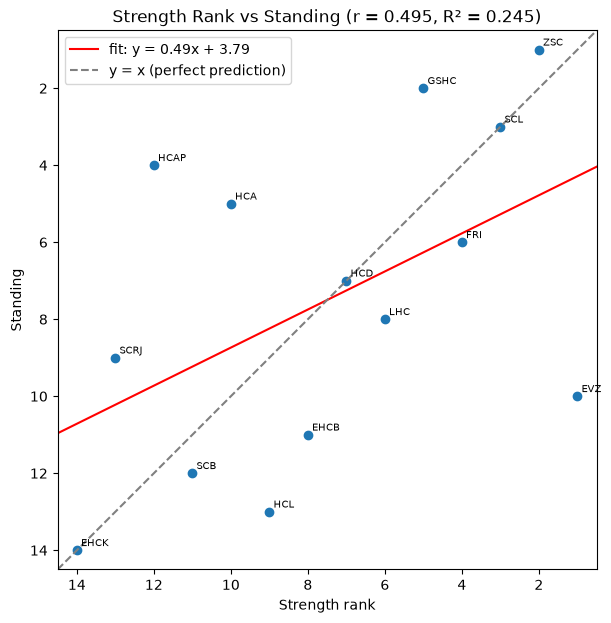

In [19]:
fx = strength_df["strength_rank"].to_numpy()
sy = strength_df["standing"].to_numpy()
teams = strength_df["team_accronym"].to_list()

r = np.corrcoef(fx, sy)[0, 1]
slope, intercept = np.polyfit(fx, sy, 1)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(fx, sy)

# team labels
for t, xi, yi in zip(teams, fx, sy):
    ax.annotate(t, (xi, yi), fontsize=7, xytext=(3, 3), textcoords="offset points")

# fitted line + perfect-prediction line
lims = np.array([14.5, .5])  # min and max for x and y axes
ax.plot(lims, slope * lims + intercept, color="red", label=f"fit: y = {slope:.2f}x + {intercept:.2f}")
ax.plot(lims, lims, color="gray", linestyle="--", label="y = x (perfect prediction)")

ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect("equal")
ax.set_xlabel("Strength rank")
ax.set_ylabel("Standing")
ax.set_title(f"Strength Rank vs Standing (r = {r:.3f}, R² = {r**2:.3f})")
ax.legend()
plt.show()